In [69]:
import pandas as pd

day_1_prices = pd.read_csv("../../data/round_4/prices_round_4_day_1.csv", sep=";")
day_2_prices = pd.read_csv("../../data/round_4/prices_round_4_day_2.csv", sep=";")
day_3_prices = pd.read_csv("../../data/round_4/prices_round_4_day_3.csv", sep=";")

day_1_trades = pd.read_csv("../../data/round_4/trades_round_4_day_1.csv", sep=";")
day_2_trades = pd.read_csv("../../data/round_4/trades_round_4_day_2.csv", sep=";")
day_3_trades = pd.read_csv("../../data/round_4/trades_round_4_day_3.csv", sep=";")

day_1_prices["day"] = 1
day_2_prices["day"] = 2
day_3_prices["day"] = 3

day_1_trades["day"] = 1
day_2_trades["day"] = 2
day_3_trades["day"] = 3

all_prices = pd.concat(
    [day_1_prices, day_2_prices, day_3_prices],
    ignore_index=True
)

all_trades = pd.concat(
    [day_1_trades, day_2_trades, day_3_trades],
    ignore_index=True
)

all_prices["global_time"] = all_prices["day"] * 1_000_000 + all_prices["timestamp"]
all_trades["global_time"] = all_trades["day"] * 1_000_000 + all_trades["timestamp"]

DELTA_ONE_PRODUCTS = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
]

VOUCHERS = [
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
    "VEV_6000",
    "VEV_6500",
]

ALL_PRODUCTS = DELTA_ONE_PRODUCTS + VOUCHERS

prices_by_product = {
    product: all_prices[all_prices["product"] == product].copy()
    for product in ALL_PRODUCTS
}

trades_by_product = {
    product: all_trades[all_trades["symbol"] == product].copy()
    for product in ALL_PRODUCTS
}

hydro_prices = prices_by_product["HYDROGEL_PACK"]
fruit_prices = prices_by_product["VELVETFRUIT_EXTRACT"]

hydro_trades = trades_by_product["HYDROGEL_PACK"]
fruit_trades = trades_by_product["VELVETFRUIT_EXTRACT"]

vev_4000_prices = prices_by_product["VEV_4000"]
vev_4500_prices = prices_by_product["VEV_4500"]
vev_5000_prices = prices_by_product["VEV_5000"]
vev_5100_prices = prices_by_product["VEV_5100"]
vev_5200_prices = prices_by_product["VEV_5200"]
vev_5300_prices = prices_by_product["VEV_5300"]
vev_5400_prices = prices_by_product["VEV_5400"]
vev_5500_prices = prices_by_product["VEV_5500"]
vev_6000_prices = prices_by_product["VEV_6000"]
vev_6500_prices = prices_by_product["VEV_6500"]

vev_4000_trades = trades_by_product["VEV_4000"]
vev_4500_trades = trades_by_product["VEV_4500"]
vev_5000_trades = trades_by_product["VEV_5000"]
vev_5100_trades = trades_by_product["VEV_5100"]
vev_5200_trades = trades_by_product["VEV_5200"]
vev_5300_trades = trades_by_product["VEV_5300"]
vev_5400_trades = trades_by_product["VEV_5400"]
vev_5500_trades = trades_by_product["VEV_5500"]
vev_6000_trades = trades_by_product["VEV_6000"]
vev_6500_trades = trades_by_product["VEV_6500"]

voucher_prices = all_prices[all_prices["product"].isin(VOUCHERS)].copy()
voucher_trades = all_trades[all_trades["symbol"].isin(VOUCHERS)].copy()

voucher_prices["strike"] = voucher_prices["product"].str.replace("VEV_", "").astype(int)
voucher_trades["strike"] = voucher_trades["symbol"].str.replace("VEV_", "").astype(int)

all_prices["tte"] = 4
all_trades["tte"] = 4

voucher_prices["tte"] = 4
voucher_trades["tte"] = 4

In [70]:
vev_4000_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
7,1,0,VEV_4000,1235,15,1232.0,27.0,NaN,NaN,1255,15,1258.0,27.0,NaN,NaN,1245.0,0.0,1000000
17,1,100,VEV_4000,1235,7,1233.0,20.0,NaN,NaN,1256,7,1259.0,20.0,NaN,NaN,1245.5,0.0,1000100
27,1,200,VEV_4000,1236,13,1233.0,26.0,NaN,NaN,1257,13,1259.0,26.0,NaN,NaN,1246.5,0.0,1000200
44,1,300,VEV_4000,1237,15,1234.0,16.0,NaN,NaN,1258,15,1260.0,16.0,NaN,NaN,1247.5,0.0,1000300
55,1,400,VEV_4000,1237,7,1234.0,15.0,NaN,NaN,1258,7,1260.0,15.0,NaN,NaN,1247.5,0.0,1000400


In [71]:
hydro_trades["buyer"].value_counts()

buyer
Mark 38    515
Mark 14    496
Mark 22     11
Name: count, dtype: int64

In [72]:
hydro_22_buys = hydro_trades[hydro_trades["buyer"] == "Mark 22"]
hydro_22_sells = hydro_trades[hydro_trades["seller"] == "Mark 14"]
hydro_22_bbuys = hydro_22_buys[hydro_22_buys["quantity"] == 4]
hydro_22_bsells = hydro_22_sells[hydro_22_sells["quantity"] == 4]

hydro_14_buys = hydro_trades[hydro_trades["buyer"] == "Mark 14"]
hydro_14_sells = hydro_trades[hydro_trades["seller"] == "Mark 14"]
hydro_14_bbuys = hydro_14_buys[hydro_14_buys["quantity"] == 4]
hydro_14_bsells = hydro_14_sells[hydro_14_sells["quantity"] == 4]

hydro_38_buys = hydro_trades[hydro_trades["buyer"] == "Mark 38"]
hydro_38_sells = hydro_trades[hydro_trades["seller"] == "Mark 38"]
hydro_38_bbuys = hydro_38_buys[hydro_38_buys["quantity"] == 5]
hydro_38_bsells = hydro_38_sells[hydro_38_sells["quantity"] == 5]
hydro_38_buys["quantity"].value_counts()

quantity
6    112
4    107
2    105
3    100
5     91
Name: count, dtype: int64

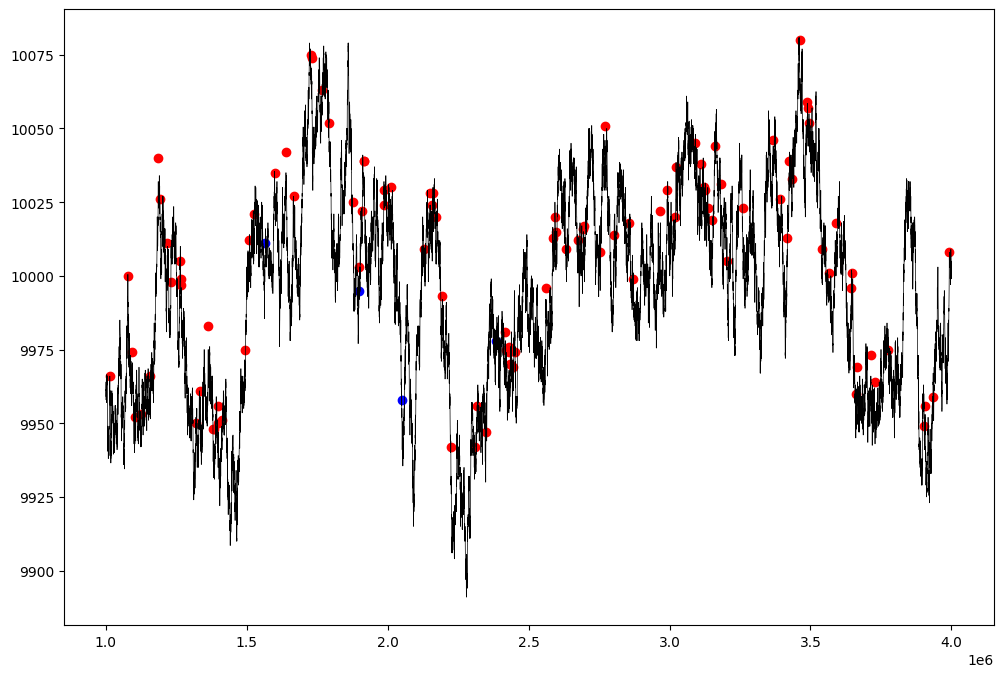

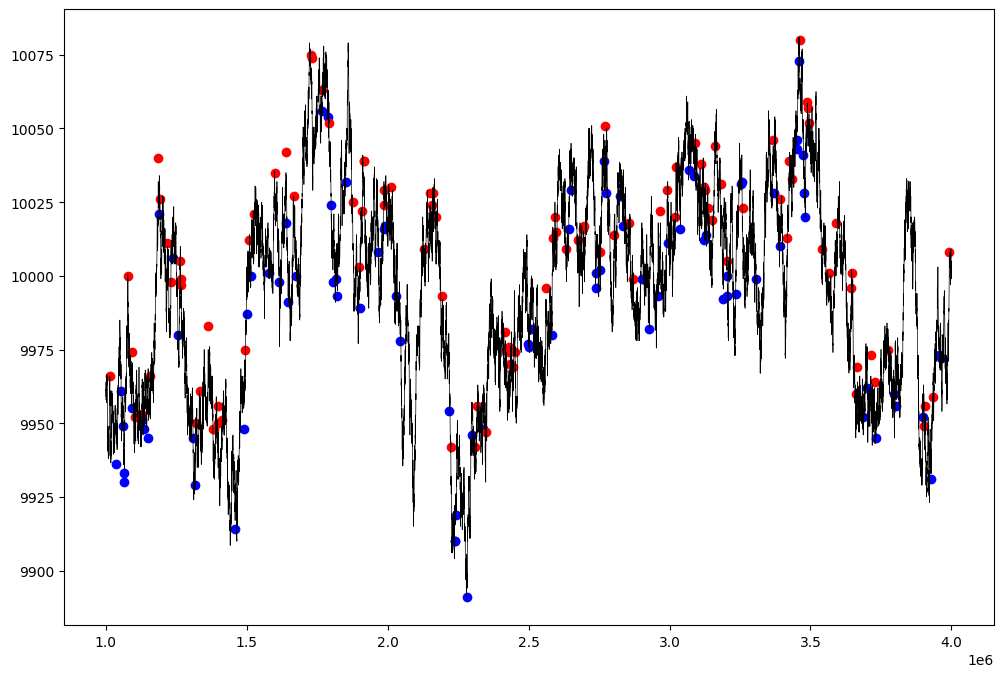

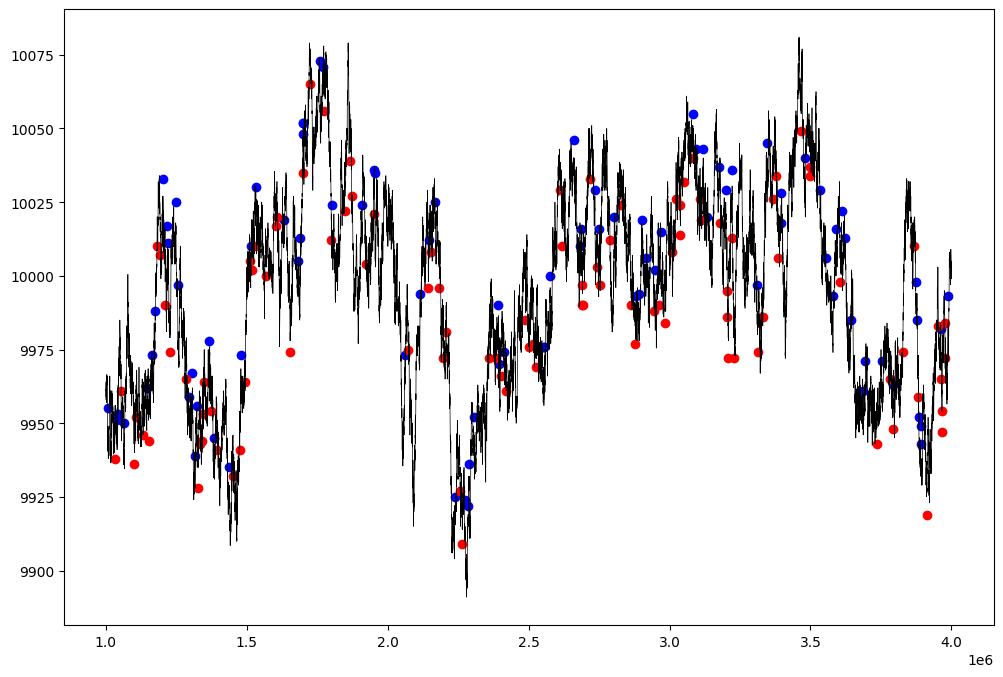

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(hydro_prices["global_time"], hydro_prices["mid_price"], lw=.5, color="black")
plt.scatter(hydro_22_bbuys["global_time"], hydro_22_bbuys["price"], color="blue")
plt.scatter(hydro_22_bsells["global_time"], hydro_22_bsells["price"], color="red")

plt.figure(figsize=(12, 8))
plt.plot(hydro_prices["global_time"], hydro_prices["mid_price"], lw=.5, color="black")
plt.scatter(hydro_14_bbuys["global_time"], hydro_14_bbuys["price"], color="blue")
plt.scatter(hydro_14_bsells["global_time"], hydro_14_bsells["price"], color="red")

plt.figure(figsize=(12, 8))
plt.plot(hydro_prices["global_time"], hydro_prices["mid_price"], lw=.5, color="black")
plt.scatter(hydro_38_bbuys["global_time"], hydro_38_bbuys["price"], color="blue")
plt.scatter(hydro_38_bsells["global_time"], hydro_38_bsells["price"], color="red")

Text(0.5, 1.0, '6500')

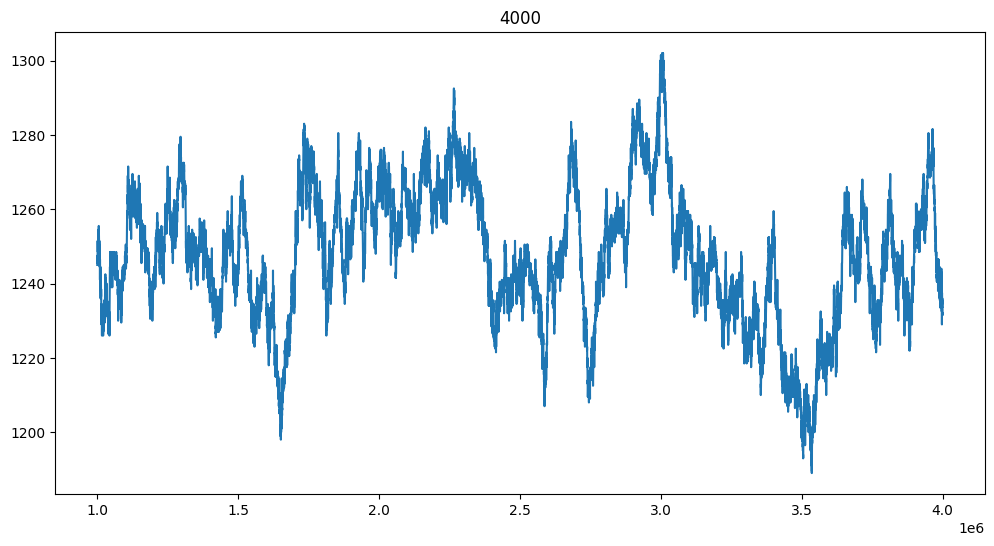

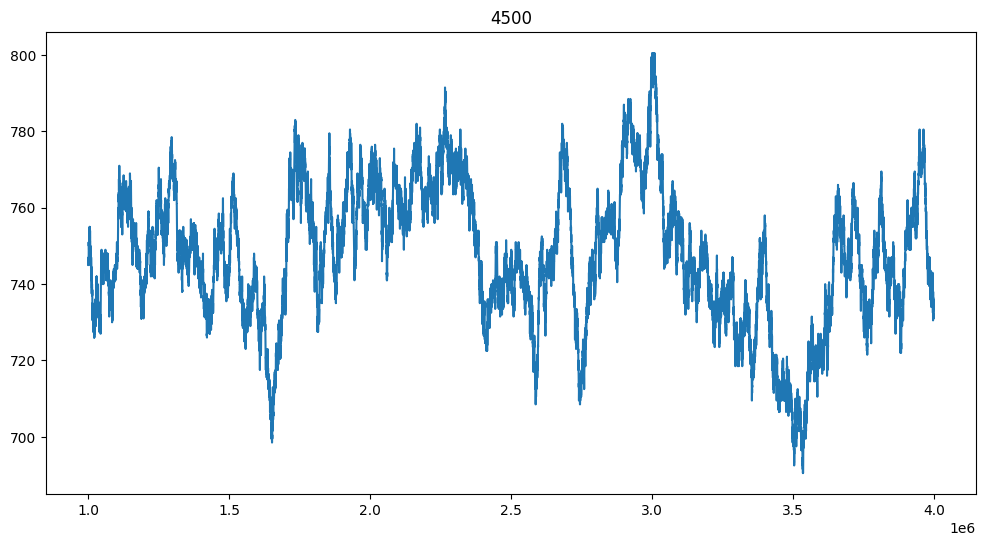

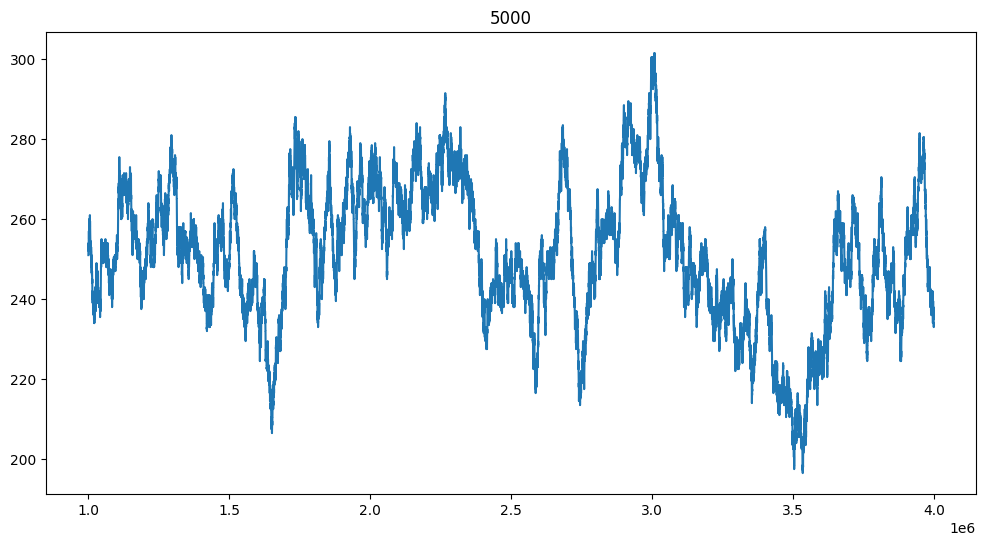

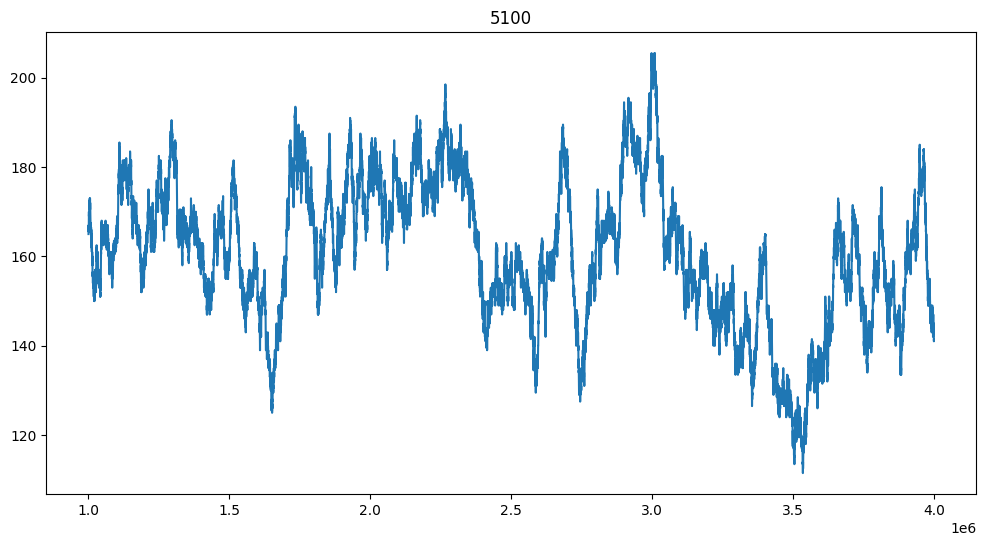

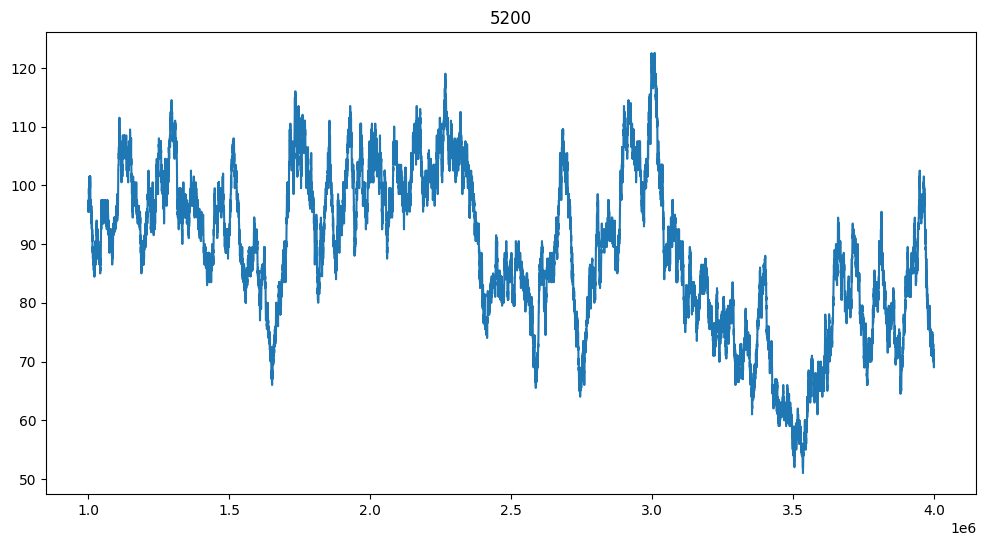

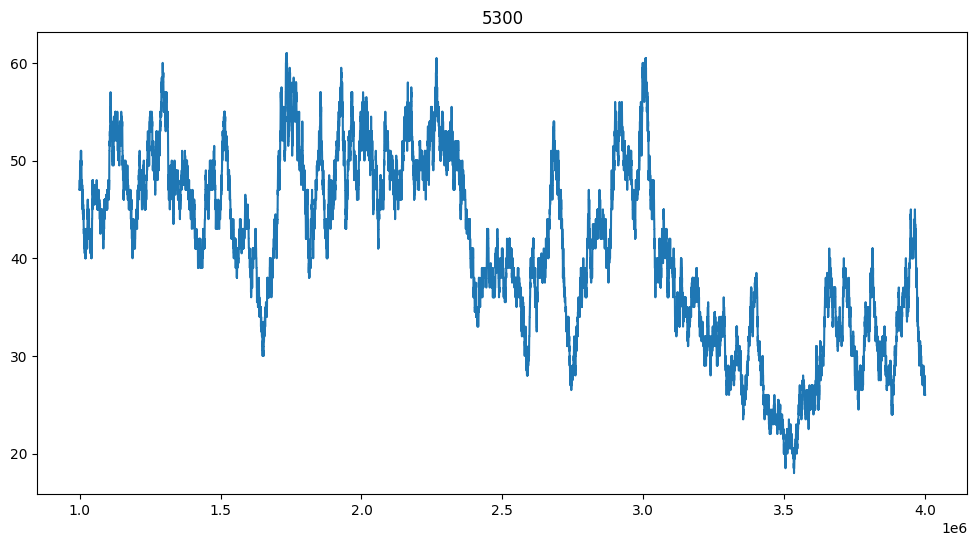

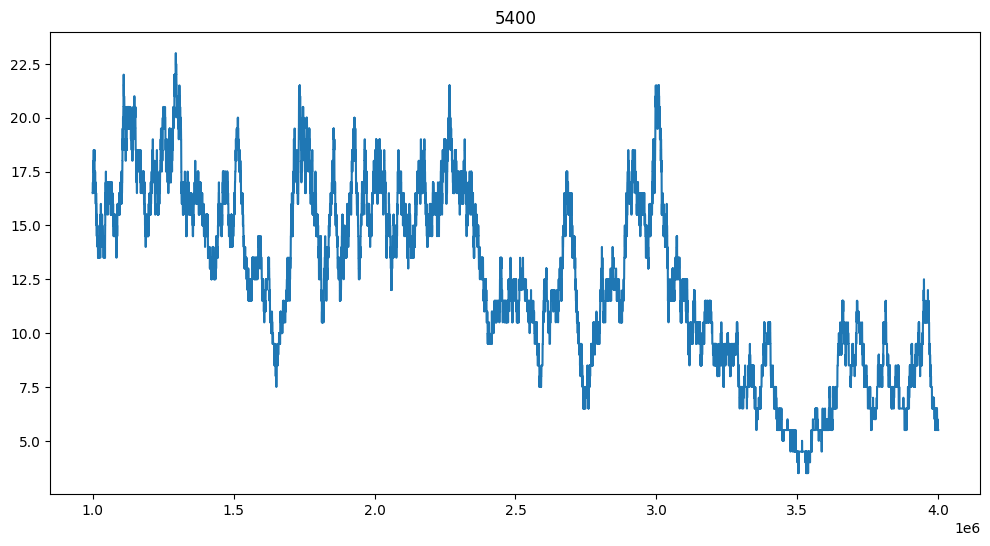

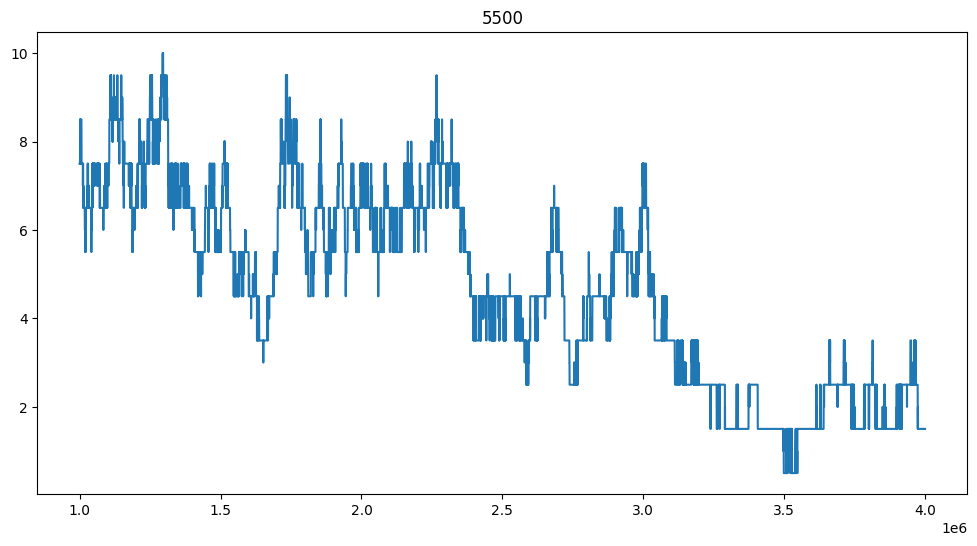

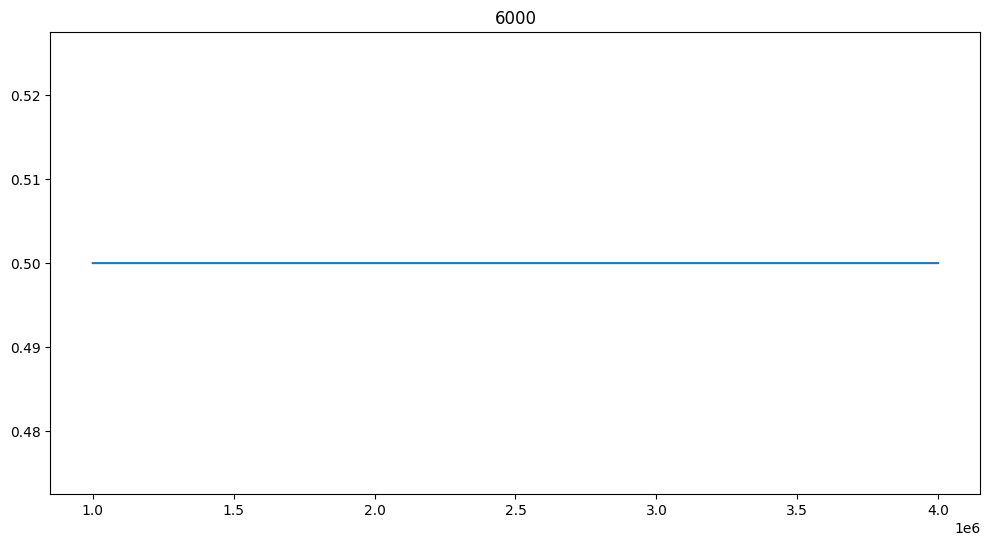

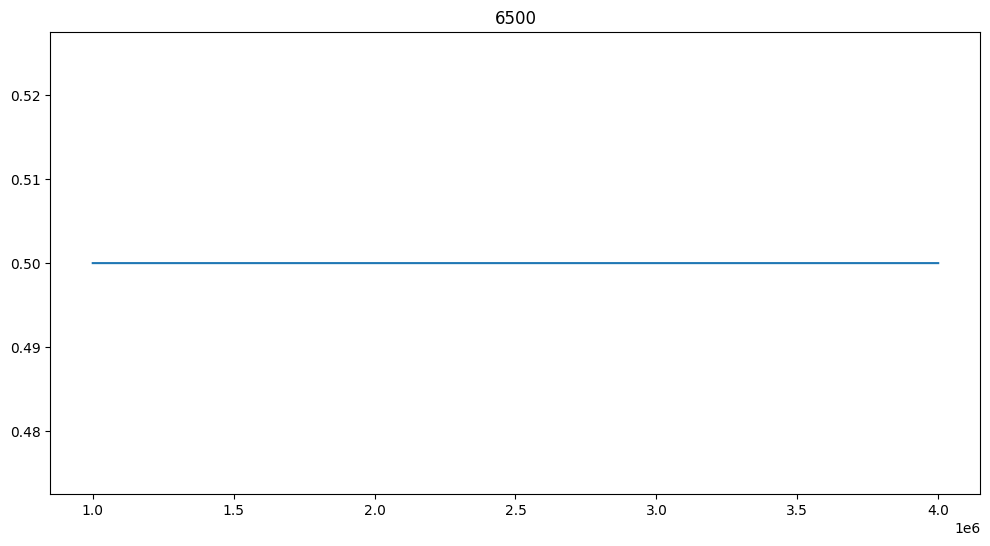

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(vev_4000_prices["global_time"], vev_4000_prices["mid_price"])
plt.title("4000")

plt.figure(figsize=(12, 6))
plt.plot(vev_4500_prices["global_time"], vev_4500_prices["mid_price"])
plt.title("4500")

plt.figure(figsize=(12, 6))
plt.plot(vev_5000_prices["global_time"], vev_5000_prices["mid_price"])
plt.title("5000")

plt.figure(figsize=(12, 6))
plt.plot(vev_5100_prices["global_time"], vev_5100_prices["mid_price"])
plt.title("5100")

plt.figure(figsize=(12, 6))
plt.plot(vev_5200_prices["global_time"], vev_5200_prices["mid_price"])
plt.title("5200")

plt.figure(figsize=(12, 6))
plt.plot(vev_5300_prices["global_time"], vev_5300_prices["mid_price"])
plt.title("5300")

plt.figure(figsize=(12, 6))
plt.plot(vev_5400_prices["global_time"], vev_5400_prices["mid_price"])
plt.title("5400")

plt.figure(figsize=(12, 6))
plt.plot(vev_5500_prices["global_time"], vev_5500_prices["mid_price"])
plt.title("5500")

plt.figure(figsize=(12, 6))
plt.plot(vev_6000_prices["global_time"], vev_6000_prices["mid_price"])
plt.title("6000")

plt.figure(figsize=(12, 6))
plt.plot(vev_6500_prices["global_time"], vev_6500_prices["mid_price"])
plt.title("6500")